## **Directions**
Explore GeoPandas and create three new spatial layers using geoprocessing techniques. Each new layer must:

Use two different input layers
Use a different geoprocessing method
Build on a different spatial question or on the results of a previous analysis

You must also create:

One new layer using a table/attribute join. For example, you could join county polygons to a table containing census data. The resulting layer would contain both the county geometries and the census attributes.

One analysis using a spatial join that produces a meaningful tabular result. For example, you could spatially join hospitals to counties and then aggregate the results by county to determine the number of hospitals in each county.


### **Main Question: How does data center loaction relate to socioeconomic conditions and the placement of public institutions?**

Why: I hear a lot online about how data centers are placed in locations that harm low-income communities, such as being located by affordable housing options. People near data centers suffer from the environmental pollutants, water reduction, and extremely loud noise pollution. Knowing this, I was also interested to see how close data centers are to public institutions, like schools.

**The data I will be using for this question is:**
- NC Public Schools data 2023
- NC Counties data
- SNAP data (food and nutrition services) 2024
- NC data center locations 2026

Data:
Percent of households receiving SNAP benefits in North Carolina in 2024: https://services.arcgis.com/ycIuRaoIC4UuCDAS/arcgis/rest/services/SNAP_2024_WFL1/FeatureServer

Data displaying nc counties boundaries: https://unc.maps.arcgis.com/apps/mapviewer/index.html?layers=4db9b66c15c94f9b932861ded2b6cf9b

NC data centers: https://malachi.energy/data-centers/north-carolina?utm_source=chatgpt.com

NC public schools: https://data-nconemap.opendata.arcgis.com/datasets/dea6ff0e8b4743a0ba361e13a85a4c70_3/explore?location=35.619238%2C-79.008864%2C8

In [149]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [150]:
#load counties data
counties = gpd.read_file("data/NCcounties.json")

counties.head()

,OBJECTID,County,FIPS,Rec_Survey,NCGS_url,ck_date,Shape__Area,Shape__Length,GlobalID,geometry
0,1,Alamance,001,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,1736726400000,1.210717e+10,476733.362073,acd66e2b-e702-4b3a-82c1-eb86e12d3804,"POLYGON ((-79.25882 36.17252, -79.25959 36.133..."
1,2,Alexander,003,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,1736726400000,7.343450e+09,387342.137292,6a1dac25-2574-4182-b77b-0074a5482dac,"POLYGON ((-81.10951 35.7766, -81.10973 35.7768..."
2,3,Alleghany,005,No recent survey data available,,1322524800000,6.576362e+09,439166.717185,d8e726fa-ac7d-4212-a981-6ea0b111cee0,"POLYGON ((-81.25365 36.3666, -81.25325 36.3668..."
3,4,Anson,007,No recent survey data available,,1322524800000,1.497020e+10,575503.754866,e4518706-732a-4abe-9079-9de6523b4747,"POLYGON ((-80.27683 35.19573, -80.27662 35.195..."
4,5,Ashe,009,Recorded survey data is available. Visit North...,https://ncem-gis.maps.arcgis.com/apps/webappvi...,1736726400000,1.193926e+10,520084.244333,6d39c7ea-b7f4-4ac8-be47-65dfe4a46074,"POLYGON ((-81.47731 36.24026, -81.48632 36.241..."


In [151]:
#inspect counties data
print(counties.shape)
print(counties.crs)
counties.columns

(100, 10)
EPSG:4326


Index(['OBJECTID', 'County', 'FIPS', 'Rec_Survey', 'NCGS_url', 'ck_date',
       'Shape__Area', 'Shape__Length', 'GlobalID', 'geometry'],
      dtype='str')

In [152]:
ncschools = gpd.read_file("data/Public_Schools.geojson")

In [153]:
print(ncschools.columns)
print(ncschools.shape)
print(ncschools.crs)

Index(['objectid', 'lea_school', 'ptmoved', 'comments', 'reviewed',
       'school_nam', 'principal', 'street_lon', 'phys_addr', 'phys_city',
       'phys_zip', 'phone', 'mail_addr', 'mail_city', 'mail_zip', 'fax',
       'url_addres', 'county', 'accr_stat', 'sch_desg', 'sch_type',
       'sch_ptype', 'sch_ctype', 'ext_hours', 'num_teach', 'bgn_grade',
       'end_grade', 'pre_k', 'elem', 'middle', 'high', 'early_coll',
       'geometry'],
      dtype='str')
(2594, 33)
EPSG:4326


In [154]:
ncschools.head()

,objectid,lea_school,ptmoved,comments,reviewed,school_nam,principal,street_lon,phys_addr,phys_city,...,ext_hours,num_teach,bgn_grade,end_grade,pre_k,elem,middle,high,early_coll,geometry
0,1,70310,"yes, 2012",across town,1,B C Ed Tech Center,Willard Bryant,820 North Bridge St,820 North Bridge St,Washington,...,-,9,06,12,,,yes,yes,,POINT (-77.05613 35.55269)
1,2,70340,"yes, 2012",down the street,1,S W Snowden Elementary,Melissa Dana,6921 NC 306 North,693 North 7th Street,Aurora,...,-,15,PK,08,yes,yes,yes,,,POINT (-76.79188 35.30652)
2,3,70326,,,,Chocowinity Primary,Alicia Vosburgh,606 Gray Road,606 Gray Road,Chocowinity,...,-,33,PK,04,yes,yes,,,,POINT (-77.09387 35.49888)
3,4,70308,,point verified,1,Bath Elementary,Pamela Hodges,110 S King Street,110 S King Street,Bath,...,-,39,KG,08,,,yes,,,POINT (-76.81073 35.4758)
4,5,740309,,,,AydenGrifton High,Marty Baker,7653 NC 11 South,7653 NC 11 South,Ayden,...,-,48,09,12,,,,yes,,POINT (-77.43122 35.43017)


In [155]:
#change crs
ncschools = ncschools.to_crs("EPSG:32119")

In [156]:
#load snap data
snap = gpd.read_file("data/SNAP.json")

snap.head()

,FID,GEOID,county,st_fips,co_fips,tr_fips,tr_name,pop_E,pop_M,snp_d_E,...,ins_c_M,ins_d_E,ins_d_M,pct_snp,pct_v_c,pct_vet,pct_unins,Shape__Area,Shape__Length,geometry
0,1,37037020600,Chatham,37,037,020600,0206.00,4631,756,1944,...,3.8,4614,756,5.2,12.9,11.6,7.0,4.635351e+08,132561.480918,"POLYGON ((-79.40217 35.59187, -79.40128 35.593..."
1,2,37105030102,Lee,37,105,030102,0301.02,5857,583,2143,...,3.8,5839,583,6.7,19.6,7.7,10.0,2.390349e+07,24875.978773,"POLYGON ((-79.23063 35.45868, -79.22612 35.463..."
2,3,37165010101,Scotland,37,165,010101,0101.01,3063,322,1324,...,4.4,2997,321,14.2,16.6,8.1,11.9,2.298304e+07,21761.918611,"POLYGON ((-79.52791 34.74421, -79.52571 34.745..."
3,4,37133000800,Onslow,37,133,000800,0008.00,829,205,377,...,3.9,451,143,1.1,60.3,8.2,2.7,2.240970e+06,8275.259708,"POLYGON ((-77.3538 34.73453, -77.35148 34.7368..."
4,5,37015960300,Bertie,37,015,960300,9603.00,3066,451,1402,...,4.8,3064,451,28.0,15.3,3.9,9.8,8.124723e+08,213278.602857,"POLYGON ((-77.32762 36.07625, -77.32637 36.076..."


In [157]:
print(snap.shape)
print(snap.crs)
print(snap.columns)

(2000, 32)
EPSG:4326
Index(['FID', 'GEOID', 'county', 'st_fips', 'co_fips', 'tr_fips', 'tr_name',
       'pop_E', 'pop_M', 'snp_d_E', 'snp_d_M', 'snap_E', 'snap_M', 'v_cv__E',
       'v_cv__M', 'va_cv_E', 'va_cv_M', 'vt_dn_E', 'vt_dn_M', 'vet_E', 'vet_M',
       'ins_c_E', 'ins_c_M', 'ins_d_E', 'ins_d_M', 'pct_snp', 'pct_v_c',
       'pct_vet', 'pct_unins', 'Shape__Area', 'Shape__Length', 'geometry'],
      dtype='str')


In [158]:
#data centers data
data_centers = pd.read_csv("data/ncdata-centers.csv")

data_centers.head()

,name,operator,city,state,address,postcode,lat,lon,website,osm_type,osm_id,osm_url,address_basis,address_source
0,NaN,NaN,NaN,NC,NaN,NaN,35.588108,-81.262575,NaN,way,116005354,https://www.openstreetmap.org/way/116005354,NaN,NaN
1,NaN,NaN,NaN,NC,NaN,NaN,35.892676,-81.546755,NaN,way,844372538,https://www.openstreetmap.org/way/844372538,NaN,NaN
2,Brandaleone Lab for Data and Visualization,Duke Libraries,NaN,NC,NaN,NaN,36.003099,-78.938532,NaN,node,10567817971,https://www.openstreetmap.org/node/10567817971,NaN,NaN
3,DartPoints Asheville,NaN,Asheville,NC,100 Technology Drive,28803.0,35.488317,-82.557536,https://dartpoints.com/locations/avl01-ashevil...,node,14124835505,https://www.openstreetmap.org/node/14124835505,osm,NaN
4,iGLASS Networks,NaN,Cary,NC,211 Commonwealth Court,27511.0,35.766751,-78.783987,NaN,way,758278314,https://www.openstreetmap.org/way/758278314,osm,NaN


In [159]:
#inspect data centers data
print(data_centers.shape)
data_centers.columns

(26, 14)


Index(['name', 'operator', 'city', 'state', 'address', 'postcode', 'lat',
       'lon', 'website', 'osm_type', 'osm_id', 'osm_url', 'address_basis',
       'address_source'],
      dtype='str')

In [160]:
#converting data centers to a GeoDataFrame because it has lat/lon coordinates
data_centers = gpd.GeoDataFrame(
    data_centers,
    geometry=gpd.points_from_xy(
        data_centers["lon"],
        data_centers["lat"]
    ),
    crs="EPSG:4326"
)

data_centers.head()

,name,operator,city,state,address,postcode,lat,lon,website,osm_type,osm_id,osm_url,address_basis,address_source,geometry
0,NaN,NaN,NaN,NC,NaN,NaN,35.588108,-81.262575,NaN,way,116005354,https://www.openstreetmap.org/way/116005354,NaN,NaN,POINT (-81.26258 35.58811)
1,NaN,NaN,NaN,NC,NaN,NaN,35.892676,-81.546755,NaN,way,844372538,https://www.openstreetmap.org/way/844372538,NaN,NaN,POINT (-81.54676 35.89268)
2,Brandaleone Lab for Data and Visualization,Duke Libraries,NaN,NC,NaN,NaN,36.003099,-78.938532,NaN,node,10567817971,https://www.openstreetmap.org/node/10567817971,NaN,NaN,POINT (-78.93853 36.0031)
3,DartPoints Asheville,NaN,Asheville,NC,100 Technology Drive,28803.0,35.488317,-82.557536,https://dartpoints.com/locations/avl01-ashevil...,node,14124835505,https://www.openstreetmap.org/node/14124835505,osm,NaN,POINT (-82.55754 35.48832)
4,iGLASS Networks,NaN,Cary,NC,211 Commonwealth Court,27511.0,35.766751,-78.783987,NaN,way,758278314,https://www.openstreetmap.org/way/758278314,osm,NaN,POINT (-78.78399 35.76675)


**Data Cleaning**

In [161]:
#check for missing values- should return zero
snap[["GEOID", "county", "pop_E", "snap_E", "pct_snp", "geometry"]].isna().sum()


GEOID       0
county      0
pop_E       0
snap_E      0
pct_snp     0
geometry    0
dtype: int64

In [162]:
#check if percentage values makes sense
snap["pct_snp"].describe()

count    2000.000000
mean       13.672550
std        11.273041
min         0.000000
25%         5.000000
50%        11.500000
75%        19.300000
max        84.100000
Name: pct_snp, dtype: float64

In [163]:
#check to makee sure data is numeric
snap.dtypes

FID                 int32
GEOID                 str
county                str
st_fips               str
co_fips               str
tr_fips               str
tr_name               str
pop_E               int32
pop_M               int32
snp_d_E             int32
snp_d_M             int32
snap_E              int32
snap_M              int32
v_cv__E             int32
v_cv__M             int32
va_cv_E             int32
va_cv_M             int32
vt_dn_E             int32
vt_dn_M             int32
vet_E               int32
vet_M               int32
ins_c_E           float64
ins_c_M           float64
ins_d_E             int32
ins_d_M             int32
pct_snp           float64
pct_v_c           float64
pct_vet           float64
pct_unins         float64
Shape__Area       float64
Shape__Length     float64
geometry         geometry
dtype: object

In [164]:
#check data centers for missing lat/long values
data_centers[["lat", "lon"]].isna().sum()

lat    0
lon    0
dtype: int64

In [165]:
#check CRS
print(counties.crs)
print(snap.crs)
print(data_centers.crs)

EPSG:4326
EPSG:4326
EPSG:4326


**Data Preperation**
So that I can create a buffer using miles, the coordinate system must be changed from degrees.
AI was used here to help determine why and how to change it. 

In [166]:
#changing CRS to NAD83
# North Carolina State Plane Coordinate System (allows measurements in meters)
counties = counties.to_crs("EPSG:32119")
snap = snap.to_crs("EPSG:32119")
data_centers = data_centers.to_crs("EPSG:32119")

In [167]:
print(counties.crs)
print(snap.crs)
print(data_centers.crs)
print(ncschools.crs)

EPSG:32119
EPSG:32119
EPSG:32119
EPSG:32119


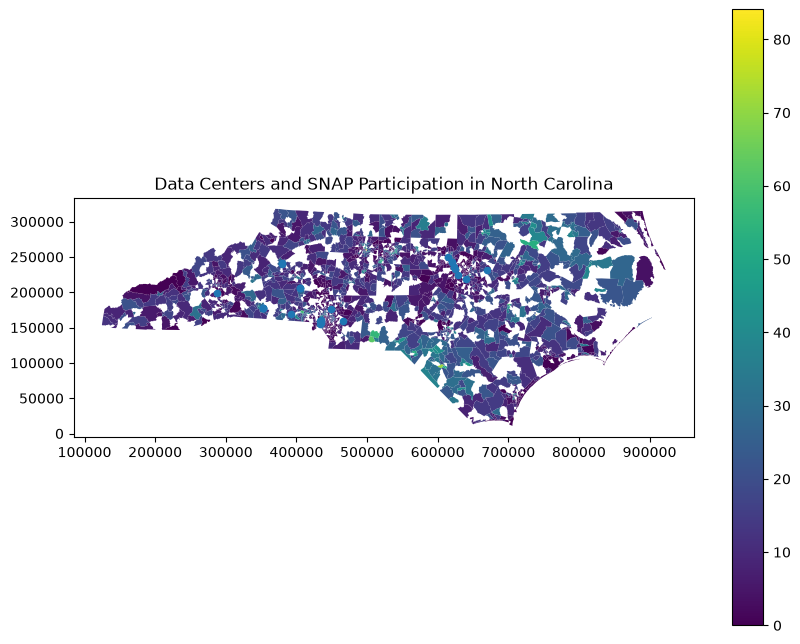

In [168]:
# SNAP and data center map
ax = snap.plot(
    column="pct_snp",
    figsize=(10, 8),
    legend=True
)

data_centers.plot(
    ax=ax,
    markersize=20
)

plt.title("Data Centers and SNAP Participation in North Carolina")
plt.show()

### **Creating First New Spatial Layer**
Displaying 5 mile buffers around NC data centers while showing county lines.
Used Clip and Buffer

In [169]:
#make a copy for editing (creating an independent geodataframe)
dc_buffers = data_centers.copy()

In [170]:
#replacing the geometry with buffers by 5 miles (8046.72 meters). Chagnes from points to polygons.
dc_buffers["geometry"] = data_centers.buffer(8046.72)
dc_buffers.head()

,name,operator,city,state,address,postcode,lat,lon,website,osm_type,osm_id,osm_url,address_basis,address_source,geometry
0,NaN,NaN,NaN,NC,NaN,NaN,35.588108,-81.262575,NaN,way,116005354,https://www.openstreetmap.org/way/116005354,NaN,NaN,"POLYGON ((412630.628 206239.318, 412591.881 20..."
1,NaN,NaN,NaN,NC,NaN,NaN,35.892676,-81.546755,NaN,way,844372538,https://www.openstreetmap.org/way/844372538,NaN,NaN,"POLYGON ((387752.547 240642.008, 387713.8 2398..."
2,Brandaleone Lab for Data and Visualization,Duke Libraries,NaN,NC,NaN,NaN,36.003099,-78.938532,NaN,node,10567817971,https://www.openstreetmap.org/node/10567817971,NaN,NaN,"POLYGON ((623189.647 249946.31, 623150.9 24915..."
3,DartPoints Asheville,NaN,Asheville,NC,100 Technology Drive,28803.0,35.488317,-82.557536,https://dartpoints.com/locations/avl01-ashevil...,node,14124835505,https://www.openstreetmap.org/node/14124835505,osm,NaN,"POLYGON ((294935.597 198615.325, 294896.85 197..."
4,iGLASS Networks,NaN,Cary,NC,211 Commonwealth Court,27511.0,35.766751,-78.783987,NaN,way,758278314,https://www.openstreetmap.org/way/758278314,osm,NaN,"POLYGON ((637179.907 223743.102, 637141.16 222..."


**Clipping 5 mile buffers to NC boundary**

In [171]:
#create one NC boundary/polygon
nc_boundary = counties.dissolve()
#dissolve() combines all geometries into a signle geometry, useful for creating a single boundary for the state.

<Axes: >

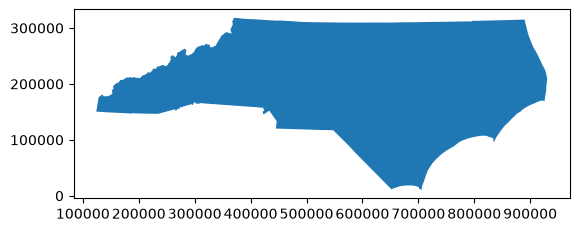

In [172]:
nc_boundary.plot()

In [173]:
#clip data center buffers to NC boundary
dc_buffers_nc = gpd.clip(dc_buffers, nc_boundary)

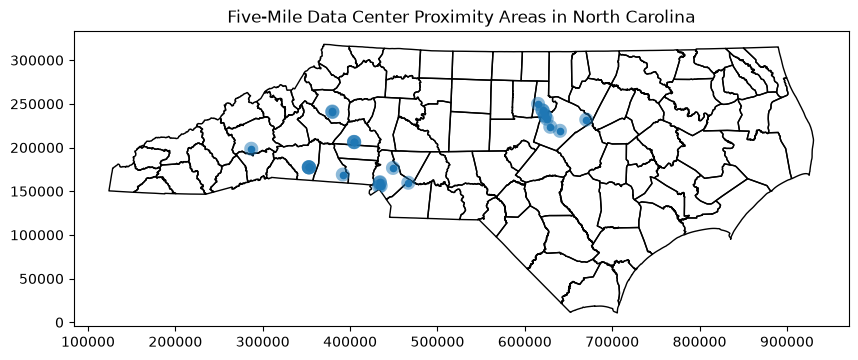

In [174]:
#Mapping new layer
ax = counties.plot(
    figsize=(10, 8),
    edgecolor="black",
    facecolor="none"
)

dc_buffers_nc.plot(
    ax=ax,
    alpha=0.5
)

data_centers.plot(
    ax=ax,
    markersize=20
)

plt.title("Five-Mile Data Center Proximity Areas in North Carolina")
plt.show()

### **Layer 2: Displaying the SNAP cencus tracts within 5 miles of NC data centers.**
Using Intersect

In [175]:
#making an intersection- keeping only the geographic areas where snap and buffers overlap.
snap_near_dc = snap[
    snap.intersects(dc_buffers_nc.union_all())
].copy()

snap_near_dc.shape

(326, 32)

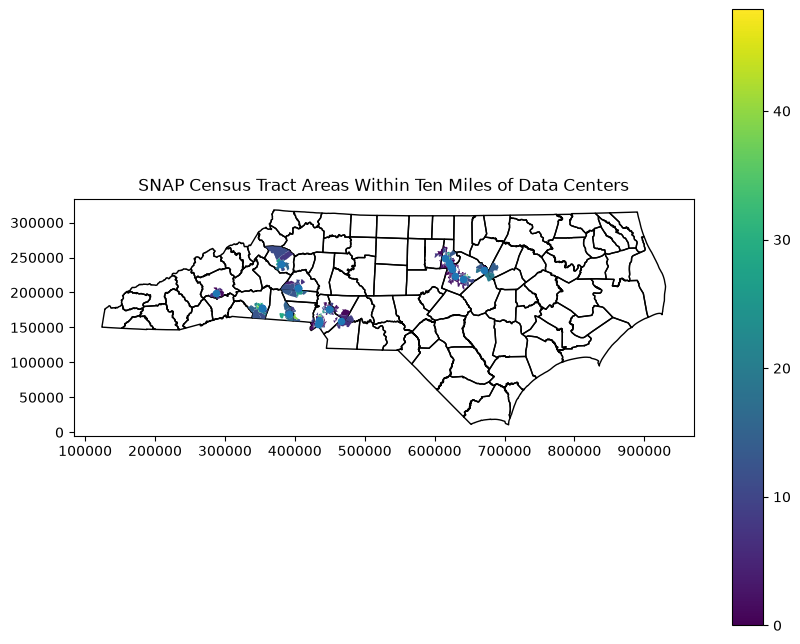

In [176]:
#Map to check that intersection worked
ax = counties.plot(
    figsize=(10, 8),
    edgecolor="black",
    facecolor="none"
)

snap_near_dc.plot(
    ax=ax,
    column="pct_snp",
    legend=True
)

data_centers.plot(
    ax=ax,
    markersize=20
)

plt.title("SNAP Census Tract Areas Within Ten Miles of Data Centers")
plt.show()

### **Layer 3: Which North Carolina public schools are located within 5 miles of a data center?**
Using within

In [177]:
#creating one data center geometry
dc_area = dc_buffers_nc.geometry.union_all()

In [ ]:
#using within() to find schools within the data center area
schools_near_dc = ncschools[
    ncschools.within(dc_area) 
].copy()

print("Total NC schools:", len(ncschools))
print("Schools within 5 miles of a data center:", len(schools_near_dc))

Total NC schools: 2594
Schools within 5 miles of a data center: 252


In [179]:
schools_near_dc[
    ["school_nam", "county", "phys_city", "sch_type"]
]

,school_nam,county,phys_city,sch_type
90,Sherwood Githens Middle,Durham,Durham,Regular School
91,DPS Hospital School,Durham,Durham,Regular School
262,Avery's Creek Elementary,Buncombe,Arden,Regular School
263,Valley Springs Middle,Buncombe,Arden,Regular School
280,Bethel Elementary,Cabarrus,Midland,Regular School
...,...,...,...,...
2574,Triangle Math and Science Academy,Wake,Cary,Regular School
2577,Wake Young Men's Leadership Academy,Wake,Raleigh,Regular School
2578,Wake Young Women's Leadership Academy,Wake,Raleigh,Regular School
2580,Research Triangle High School,Durham,Research Triangle Pa,Regular School


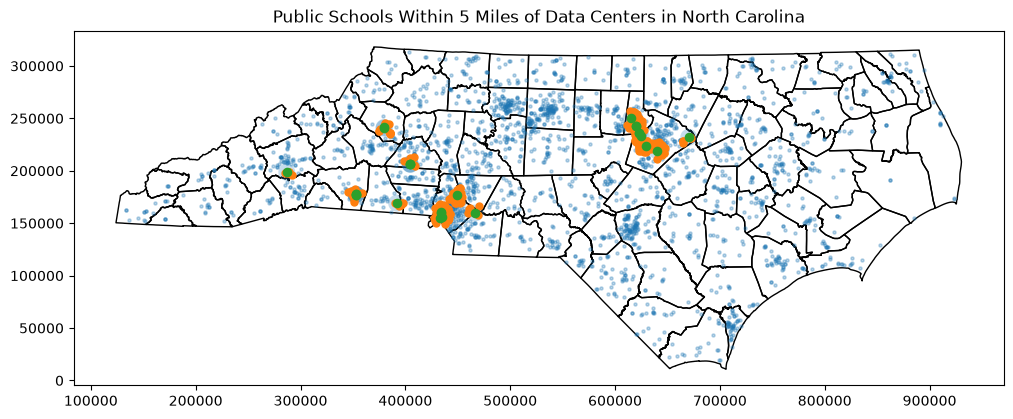

In [180]:
#Creating a map displaying public schools and those within 5 miles of data centers.
ax = counties.plot(
    figsize=(12, 8),
    edgecolor="black",
    facecolor="none"
)

dc_buffers_nc.plot(
    ax=ax,
    alpha=0.25
)

ncschools.plot(
    ax=ax,
    markersize=5,
    alpha=0.3
)

schools_near_dc.plot(
    ax=ax,
    markersize=25
)

data_centers.plot(
    ax=ax,
    markersize=35
)

plt.title("Public Schools Within 5 Miles of Data Centers in North Carolina")
plt.show()

### **Spatial Join: How many data centers are located in each North Carolina county?**

In [181]:
counties.columns

Index(['OBJECTID', 'County', 'FIPS', 'Rec_Survey', 'NCGS_url', 'ck_date',
       'Shape__Area', 'Shape__Length', 'GlobalID', 'geometry'],
      dtype='str')

In [182]:
county_col = "County"

dc_counties = gpd.sjoin(
    data_centers,
    counties[[county_col, "geometry"]],
    how="left",
    predicate="within"
)

In [183]:
#Summary Table
dc_counts = (
    dc_counties.groupby(county_col)
    .size()
    .reset_index(name="data_center_count")
)

dc_counts = dc_counts.sort_values(
    "data_center_count",
    ascending=False
)

display(dc_counts)

,County,data_center_count
4,Durham,5
5,Mecklenburg,5
6,Rutherford,4
8,Wake,4
2,Catawba,3
1,Caldwell,2
0,Buncombe,1
3,Cleveland,1
7,Union,1


A spatial join assigned each data-center point to the county containing it. The results were aggregated by county to identify where data centers are most concentrated.

### **Attribute Join: Displaying the number of data centers in each county by color.**
Creating new spatial layer through attribute join

In [184]:
counties_dc = counties.merge(
    dc_counts,
    on=county_col,
    how="left" #left keeps all counties, including those without data centers
)

In [185]:
#replace missing values
counties_dc["data_center_count"] = (
    counties_dc["data_center_count"]
    .fillna(0)
    .astype(int)
)

In [186]:
counties_dc[
    [county_col, "data_center_count"]
].head()

,County,data_center_count
0,Alamance,0
1,Alexander,0
2,Alleghany,0
3,Anson,0
4,Ashe,0


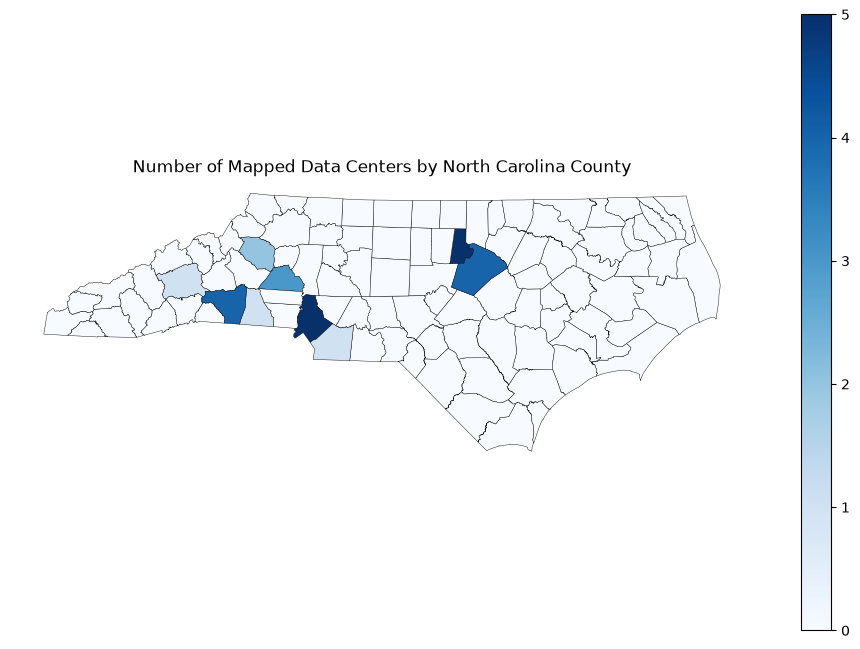

In [187]:
#Using color to display the number of data centers by county 
ax = counties_dc.plot(
    column="data_center_count",
    figsize=(12, 8),
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.3
)

plt.title("Number of Mapped Data Centers by North Carolina County")
plt.axis("off")
plt.show()

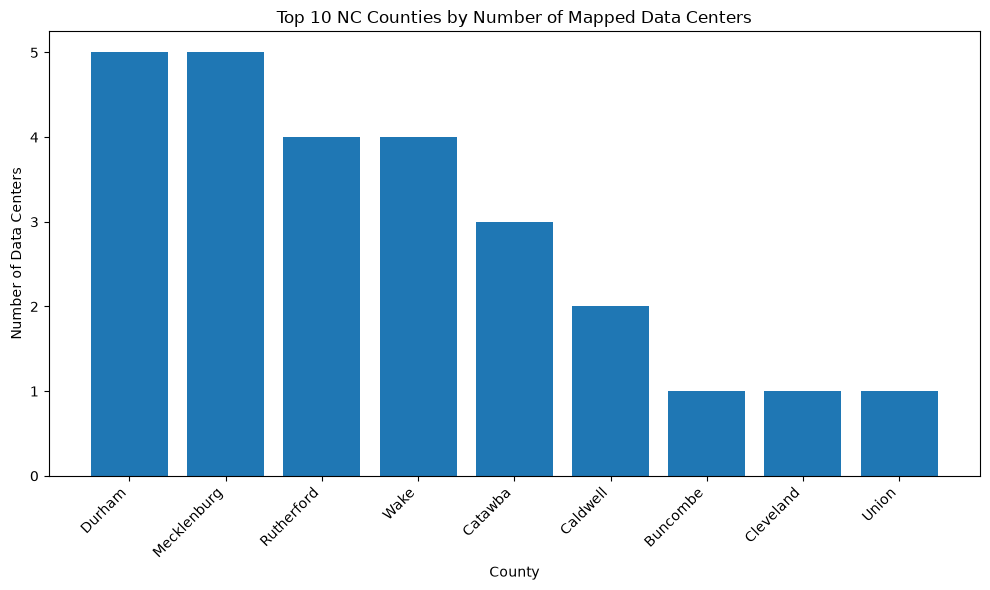

In [188]:
#Making a bar chart of the top 10 counties with the most data centers
top_counties = dc_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_counties[county_col],
    top_counties["data_center_count"]
)

plt.xlabel("County")
plt.ylabel("Number of Data Centers")
plt.title("Top 10 NC Counties by Number of Mapped Data Centers")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In conclusion, 252 public schools were within 5 miles of data centers. The 5 mile data center buffers also hold high percentages of SNAP participants, but a more comprehensive analysis is needed to truly understand that relationship in comparison to other areas of NC. Durham and Mecklenburg had the highest number of mapped data centers.

AI was used for assistance with map creation, the spatial join summary table, and for the bar chart.